In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import joblib
import sys

sys.path.append('..')

In [ ]:
from Data.DataProcess  import cut_data

def renorm(data, scale_length, L):
    N = L**3/scale_length**3
    return data * scale_length[None, :, None]**3 /N[None, :, None]

In [3]:
def data_process(data):
    mean, std = [], []
    for d in data:
        mean.append(np.mean(d,axis=0))
        std.append(np.std(d,axis=0))
    return mean, std

def combine_scale(params, scales_path):

    params = np.array(params).reshape(1,-1)
    scale = np.load(scales_path).reshape(-1,1)

    out_params = np.tile(params.squeeze(),(scale.shape[0],1))

    return np.append(out_params, scale, axis=1)


# Betti curve

In [4]:
def load_bcs_as_dict(sims, save_dir, bc_file_str, fof=True, rsd=None):
    bcs = {}
    for sim in sims:
        file_name = f'{sim}'
        if fof:
            file_name += '-fof'
        if rsd is not None:
            file_name += f'-rsd{rsd}'
        file_name += f'{bc_file_str}.npy'
        bcs[sim] = np.load(os.path.join(save_dir, file_name))[:,-500:,:]
        print(f'{file_name}: {bcs[sim].shape}')
    return bcs

In [ ]:

cuts = [range(1, 6), range(2, 15), range(9, 19)]


x = [np.array(xi)/10 for xi in cuts]


save_dir = '../Data/TestData/DimlessBC'
sims = os.listdir('/hscratch/ljy/ProcessedFoFData')
sims.remove('nwLH')

bcs = load_bcs_as_dict(sims, save_dir, '-bc', fof=False, rsd=None)
bcs_fof = load_bcs_as_dict(sims, save_dir, '-bc', fof=True, rsd=None)
bcs_fof_sub = load_bcs_as_dict(sims, save_dir, '-bcsub', fof=True, rsd=None)
bcs_fof_rsdz = load_bcs_as_dict(sims, save_dir, '-bc', fof=True, rsd='z')
bcs_fof_rsdz_sub = load_bcs_as_dict(sims, save_dir, '-bcsub', fof=True, rsd='z')

bcs_cut = {'data' : {},
              'err' : {}}
bcs_fof_cut = {'data' : {},
           'err' : {}}

bcs_fof_rsdz_cut = {'data' : {},
                'err' : {}}

bcs_fof_sub_cut = {'data' : {},
              'err' : {}}
bcs_fof_rsdz_sub_cut = {'data' : {},
                'err' : {}}


for sim in sims:
    bcs_cut['data'][sim], bcs_cut['err'][sim] = data_process(cut_data(bcs[sim], cuts))
    bcs_fof_cut['data'][sim], bcs_fof_cut['err'][sim] = data_process(cut_data(bcs_fof[sim], cuts))
    bcs_fof_rsdz_cut['data'][sim], bcs_fof_rsdz_cut['err'][sim] = data_process(cut_data(bcs_fof_rsdz[sim], cuts))

    bcs_fof_sub_cut ['data'][sim], bcs_fof_sub_cut['err'][sim] = data_process(cut_data(bcs_fof_sub[sim], cuts))
    bcs_fof_rsdz_sub_cut['data'][sim], bcs_fof_rsdz_sub_cut['err'][sim] = data_process(cut_data(bcs_fof_rsdz_sub[sim], cuts))


Ob2_p-bc.npy: (3, 500, 25)
Mnu_pp-bc.npy: (3, 500, 25)
s8_p-bc.npy: (3, 500, 25)
fiducial_ZA-bc.npy: (3, 500, 25)
fiducial-bc.npy: (3, 500, 25)
Om_p-bc.npy: (3, 500, 25)
w_p-bc.npy: (3, 500, 25)
s8_m-bc.npy: (3, 500, 25)
Om_m-bc.npy: (3, 500, 25)
Ob2_m-bc.npy: (3, 500, 25)
ns_m-bc.npy: (3, 500, 25)
h_m-bc.npy: (3, 500, 25)
h_p-bc.npy: (3, 500, 25)
Mnu_p-bc.npy: (3, 500, 25)
w_m-bc.npy: (3, 500, 25)
ns_p-bc.npy: (3, 500, 25)
Ob2_p-fof-bc.npy: (3, 500, 25)
Mnu_pp-fof-bc.npy: (3, 500, 25)
s8_p-fof-bc.npy: (3, 500, 25)
fiducial_ZA-fof-bc.npy: (3, 500, 25)
fiducial-fof-bc.npy: (3, 500, 25)
Om_p-fof-bc.npy: (3, 500, 25)
w_p-fof-bc.npy: (3, 500, 25)
s8_m-fof-bc.npy: (3, 500, 25)
Om_m-fof-bc.npy: (3, 500, 25)
Ob2_m-fof-bc.npy: (3, 500, 25)
ns_m-fof-bc.npy: (3, 500, 25)
h_m-fof-bc.npy: (3, 500, 25)
h_p-fof-bc.npy: (3, 500, 25)
Mnu_p-fof-bc.npy: (3, 500, 25)
w_m-fof-bc.npy: (3, 500, 25)
ns_p-fof-bc.npy: (3, 500, 25)
Ob2_p-fof-bcsub.npy: (3, 500, 25)
Mnu_pp-fof-bcsub.npy: (3, 500, 25)
s8_p-fof-bc

In [ ]:
# subsample test

cuts=[range(1,6), range(3,12), range(13,18)]

x0 = np.arange(0.1,0.6,0.1)
x1 = np.arange(0.3,1.2,0.1)
x2 = np.arange(1.3,1.8,0.1)

x = [x0,x1,x2]

bcs_sub= {}
bcs_sub_cut = {'data' : {},
           'err' : {}}
for root, dirs, files in os.walk('../Data/TestData/DimlessBC'):
    for file in files:
        if file.split('-')[-1] == 'bcsub.npy':
            sim = file.split('-')[0]
            bcs_sub[sim] = np.load(os.path.join(root,file))
            if sim =='fiducial':
                bcs_sub[sim] = bcs_sub[sim][:,-500:,:] # use last 500 fiducial sims
            # cut data 
            bcs_sub_cut['data'][sim], bcs_sub_cut['err'][sim] = data_process(cut_data(bcs_sub[sim], cuts))



In [ ]:
gpr0_rsd = joblib.load('./model-fof-rsdz/autosklearn_model_0.pkl')
gpr1_rsd = joblib.load('./model-fof-rsdz/autosklearn_model_1.pkl')
gpr2_rsd = joblib.load('./model-fof-rsdz/autosklearn_model_2.pkl')
gpr0 = joblib.load('./model-fof/autosklearn_model_0.pkl')
gpr1 = joblib.load('./model-fof/autosklearn_model_1.pkl')
gpr2 = joblib.load('./model-fof/autosklearn_model_2.pkl')
emulators = [gpr0, gpr1, gpr2]
emulators_rsd = [gpr0_rsd, gpr1_rsd, gpr2_rsd]

## nwLH with scale length

In [ ]:
fiducial_inputs = np.array([0.3175,0.049,0.6711,0.9624,0.834,0,-1],dtype=np.float32).reshape(1,-1)
fiducialZA_inputs = np.array([0.3175,0.049,0.6711,0.9624,0.834,0,-1],dtype=np.float32).reshape(1,-1)
Mnu_p_inputs = np.array([0.3175,0.049,0.6711,0.9624,0.834,0.1,-1],dtype=np.float32).reshape(1,-1)
Mnu_pp_inputs = np.array([0.3175,0.049,0.6711,0.9624,0.834,0.2,-1],dtype=np.float32).reshape(1,-1)
s8_m_inputs = np.array([0.3175,0.049,0.6711,0.9624,0.819,0,-1],dtype=np.float32).reshape(1,-1)
s8_p_inputs = np.array([0.3175,0.049,0.6711,0.9624,0.849,0,-1],dtype=np.float32).reshape(1,-1)
Om_m_inputs = np.array([0.3075,0.049,0.6711,0.9624,0.834,0,-1],dtype=np.float32).reshape(1,-1)
Om_p_inputs = np.array([0.3275,0.049,0.6711,0.9624,0.834,0,-1],dtype=np.float32).reshape(1,-1)
Ob2_m_inputs = np.array([0.3175,0.047,0.6711,0.9624,0.834,0,-1],dtype=np.float32).reshape(1,-1)
Ob2_p_inputs = np.array([0.3175,0.051,0.6711,0.9624,0.834,0,-1],dtype=np.float32).reshape(1,-1)
h_m_inputs = np.array([0.3175,0.049,0.6511,0.9624,0.834,0,-1],dtype=np.float32).reshape(1,-1)
h_p_inputs = np.array([0.3175,0.049,0.6911,0.9624,0.834,0,-1],dtype=np.float32).reshape(1,-1)
ns_m_inputs = np.array([0.3175,0.049,0.6711,0.9424,0.834,0,-1],dtype=np.float32).reshape(1,-1)
ns_p_inputs = np.array([0.3175,0.049,0.6711,0.9824,0.834,0,-1],dtype=np.float32).reshape(1,-1)
w_m_inputs = np.array([0.3175,0.049,0.6711,0.9624,0.834,0,-1.05],dtype=np.float32).reshape(1,-1)
w_p_inputs = np.array([0.3175,0.049,0.6711,0.9624,0.834,0,-0.95],dtype=np.float32).reshape(1,-1)

cosmo_inputs = {
    'fiducial': fiducial_inputs,
    'fiducial_ZA': fiducialZA_inputs,
    'Mnu_p': Mnu_p_inputs,
    'Mnu_pp': Mnu_pp_inputs,
    's8_m': s8_m_inputs,
    's8_p': s8_p_inputs,
    'Om_m': Om_m_inputs,
    'Om_p': Om_p_inputs,
    'Ob2_m': Ob2_m_inputs,
    'Ob2_p': Ob2_p_inputs,
    'h_m': h_m_inputs,
    'h_p': h_p_inputs,
    'ns_m': ns_m_inputs,
    'ns_p': ns_p_inputs,
    'w_m': w_m_inputs,
    'w_p': w_p_inputs
}

sub = True
fof = True

sims = cosmo_inputs.keys()

test_inputs = {}

for sim in sims:
    file_name = f'{sim}'
    if fof:
        file_name += '_fof'
    if sub:
        file_name += '_sub'
    file_name += '.npy'
    scale_path = os.path.join('../Data/TestData/scale_length', file_name)
    print(scale_path)
    test_inputs[sim] = combine_scale(cosmo_inputs[sim], scale_path)[-500:]

test_rockstar_inputs = {}
sub = False
fof = False
for sim in sims:
    file_name = f'{sim}'
    if fof:
        file_name += '_fof'
    if sub:
        file_name += '_sub'
    file_name += '.npy'
    scale_path = os.path.join('../Data/TestData/scale_length', file_name)
    print(scale_path)
    test_rockstar_inputs[sim] = combine_scale(cosmo_inputs[sim], scale_path)[-500:]


../Data/TestData/scale_length/fiducial_fof_sub.npy
../Data/TestData/scale_length/fiducial_ZA_fof_sub.npy
../Data/TestData/scale_length/Mnu_p_fof_sub.npy
../Data/TestData/scale_length/Mnu_pp_fof_sub.npy
../Data/TestData/scale_length/s8_m_fof_sub.npy
../Data/TestData/scale_length/s8_p_fof_sub.npy
../Data/TestData/scale_length/Om_m_fof_sub.npy
../Data/TestData/scale_length/Om_p_fof_sub.npy
../Data/TestData/scale_length/Ob2_m_fof_sub.npy
../Data/TestData/scale_length/Ob2_p_fof_sub.npy
../Data/TestData/scale_length/h_m_fof_sub.npy
../Data/TestData/scale_length/h_p_fof_sub.npy
../Data/TestData/scale_length/ns_m_fof_sub.npy
../Data/TestData/scale_length/ns_p_fof_sub.npy
../Data/TestData/scale_length/w_m_fof_sub.npy
../Data/TestData/scale_length/w_p_fof_sub.npy
../Data/TestData/scale_length/fiducial.npy
../Data/TestData/scale_length/fiducial_ZA.npy
../Data/TestData/scale_length/Mnu_p.npy
../Data/TestData/scale_length/Mnu_pp.npy
../Data/TestData/scale_length/s8_m.npy
../Data/TestData/scale_leng

In [11]:
import time
t = 0
for i in test_inputs:
    start = time.time()
    gpr2.predict(test_inputs[i])
    end = time.time()
    t += end - start
print(t/len(test_inputs)/500)

0.00038750597834587096


### Plot full/sub

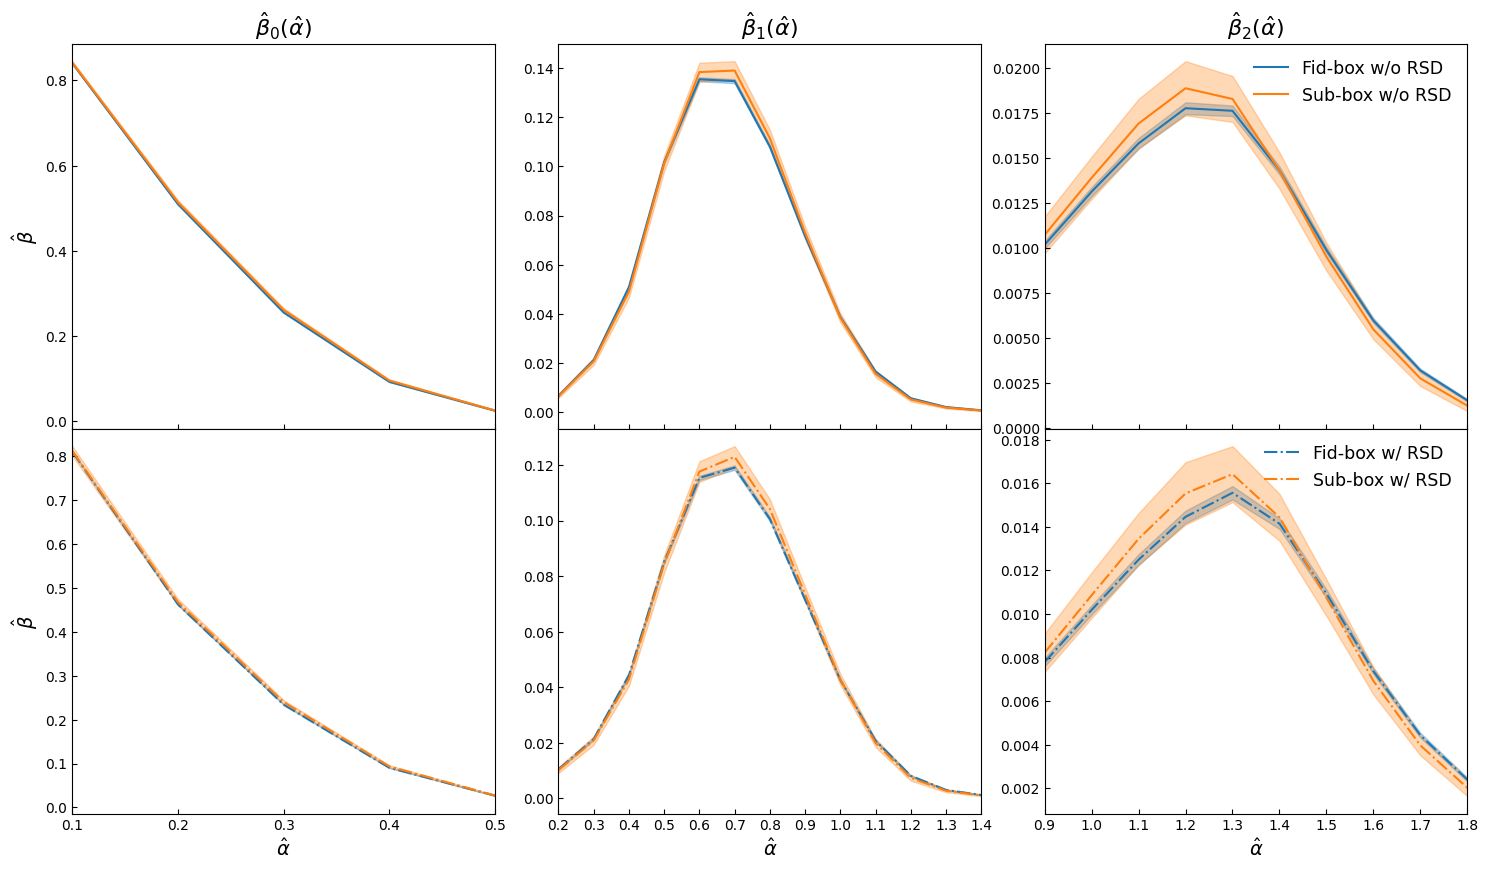

In [6]:
# plot for full & sub box comparsion (fof and fof-rsdz)
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex='col')

for i in range(3):
    ax = axes[0][i]
    # true data
    ax.plot(x[i], bcs_fof_cut['data']['fiducial_ZA'][i], color='tab:blue', label='Fid-box w/o RSD')
    ax.plot(x[i], bcs_fof_sub_cut['data']['fiducial_ZA'][i], color='tab:orange',label='Sub-box w/o RSD')

    ax.fill_between(x[i], bcs_fof_cut['data']['fiducial_ZA'][i]-bcs_fof_cut['err']['fiducial_ZA'][i], bcs_fof_cut['data']['fiducial_ZA'][i]+bcs_fof_cut['err']['fiducial_ZA'][i], color='tab:blue', alpha=0.3)
    ax.fill_between(x[i], bcs_fof_sub_cut['data']['fiducial_ZA'][i]-bcs_fof_sub_cut['err']['fiducial_ZA'][i], bcs_fof_sub_cut['data']['fiducial_ZA'][i]+bcs_fof_sub_cut['err']['fiducial_ZA'][i], color='tab:orange', alpha=0.3)
    ax.set_title(rf'$\hat\beta_{i}(\hat\alpha)$', fontsize=16)
    ax.tick_params(axis='both', direction='in')
    if i == 0:
        ax.set_ylabel(r'$\hat\beta$', fontsize=14)
    if i == 2:
        ax.legend(frameon=False, loc='upper right', fontsize=12.5)
# rsd
for i in range(3):
    ax = axes[1][i]
    # true data
    ax.plot(x[i], bcs_fof_rsdz_cut['data']['fiducial_ZA'][i], color='tab:blue', label='Fid-box w/ RSD', linestyle='-.')
    ax.plot(x[i], bcs_fof_rsdz_sub_cut['data']['fiducial_ZA'][i], color='tab:orange',label='Sub-box w/ RSD',linestyle='-.')

    ax.fill_between(x[i], bcs_fof_rsdz_cut['data']['fiducial_ZA'][i]-bcs_fof_rsdz_cut['err']['fiducial_ZA'][i], bcs_fof_rsdz_cut['data']['fiducial_ZA'][i]+bcs_fof_rsdz_cut['err']['fiducial_ZA'][i], color='tab:blue', alpha=0.3)
    ax.fill_between(x[i], bcs_fof_rsdz_sub_cut['data']['fiducial_ZA'][i]-bcs_fof_rsdz_sub_cut['err']['fiducial_ZA'][i], bcs_fof_rsdz_sub_cut['data']['fiducial_ZA'][i]+bcs_fof_rsdz_sub_cut['err']['fiducial_ZA'][i], color='tab:orange', alpha=0.3)
    # # prediction
    # fid = np.mean(emulators[i].predict(test_inputs['fiducialZA']), axis=0)
    # fid_sub = np.mean(emulators[i].predict(test_sub_inputs['fiducialZA']), axis=0)
    # ax.scatter(x[i], fid, color='tab:blue', label='Fid-box pred')
    # ax.scatter(x[i], fid_sub, color='tab:orange', label='Sub-box pred')
    ax.set_xlim([x[i][0], x[i][-1]])
    ax.set_xlabel(r'$\hat\alpha$', fontsize=14)
    ax.set_xticks(x[i])
    ax.tick_params(axis='both', direction='in')

    if i == 0:
        ax.set_ylabel(r'$\hat\beta$', fontsize=14)
    if i == 2:
        ax.legend(frameon=False, loc='upper right', fontsize=12.5)    

plt.subplots_adjust(wspace=0.15,hspace=0)
plt.savefig('/home/ljy/BettiCurveCosmo/Fig/compare_sub.pdf', bbox_inches='tight')
plt.show()

### Test emulator (FoF)

In [ ]:
# fof halos
import joblib

sims = ['fiducial_ZA', 'Om_p', 'Om_m', 's8_p', 's8_m', 'Ob2_p', 'Ob2_m', 'h_p', 'h_m', 'ns_p', 'ns_m', 'w_p', 'w_m', 'Mnu_p', 'Mnu_pp']
labels = ['Fiducial', r'$\Omega_m+0.01$', r'$\Omega_m-0.01$', r'$\sigma_8+0.015$', r'$\sigma_8-0.015$', r'$\Omega_b+0.002$', r'$\Omega_b-0.002$', r'$h+0.02$', r'$h-0.02$', r'$n_s+0.02$', r'$n_s-0.02$', r'$w+0.05$', r'$w-0.05$', r'$M_{\nu}=0.1$', r'$M_{\nu}=0.2$']
# preds = [np.array([np.mean(emulators[i].predict(test_inputs[sim][:,:-1]), axis=0) for sim in sims]) for i in range(len(emulators))]
preds = [np.array([np.mean(emulators[i].predict(test_inputs[sim]), axis=0) for sim in sims]) for i in range(len(emulators))]
err_stat = [np.stack([bcs_fof_cut['err'][sim][i] for sim in sims], axis=0) for i in range(len(emulators))]
true = [np.stack([bcs_fof_cut['data'][sim][i] for sim in sims], axis=0) for i in range(len(emulators))]
err_rela = [(preds[i]/true[i]-1) for i in range(len(emulators))]
acc = [(preds[i]-true[i])/err_stat[i] for i in range(len(emulators))]

RMSRE_sts = [np.sqrt(np.mean(acc[i]**2, axis=0)) for i in range(len(emulators))]
RMSRE = [np.sqrt(np.mean(err_rela[i]**2, axis=0)) for i in range(len(emulators))]
 

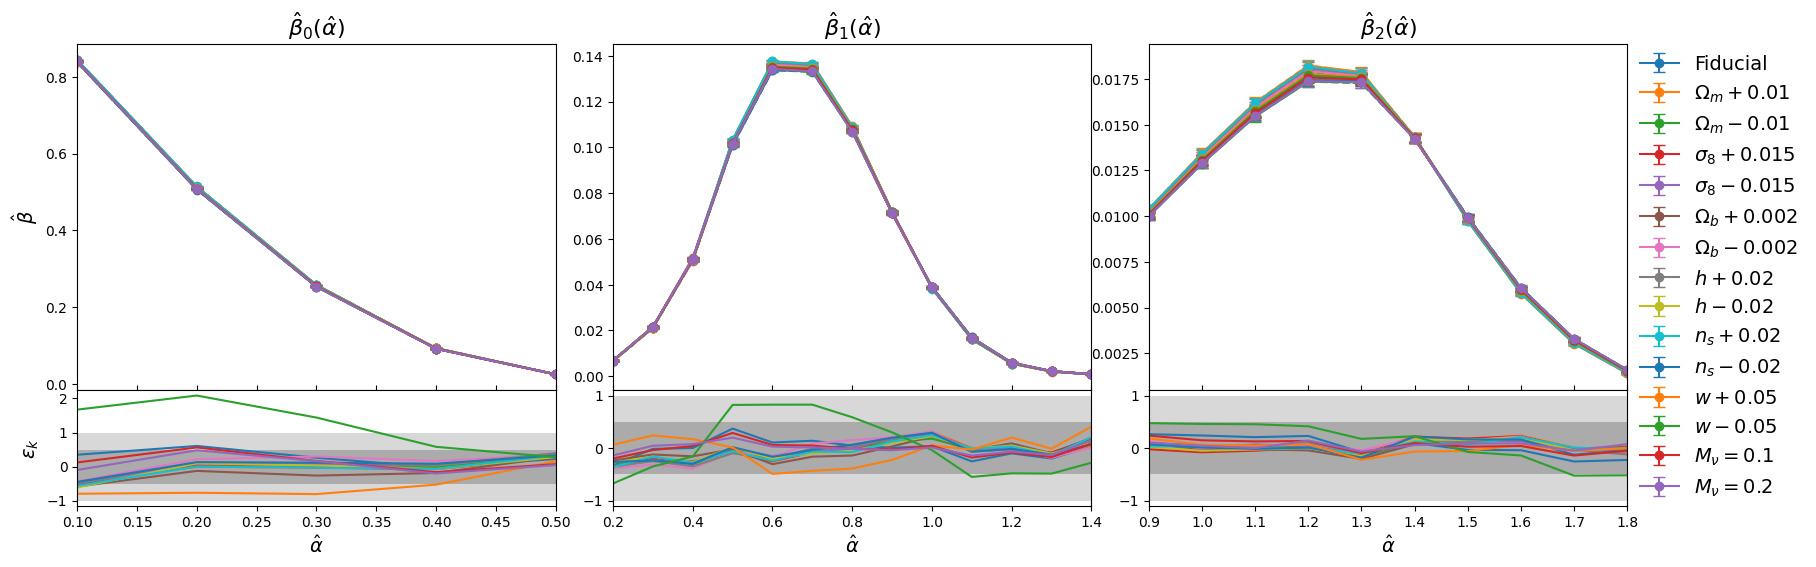

In [25]:
fig, axes = plt.subplots(2, 3, sharex='col', gridspec_kw={'height_ratios': [3, 1]}, figsize=(20,6))

for i in range(len(emulators)):
    # fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    ax1 = axes[0][i]
    ax2 = axes[1][i]
    for j in range(preds[i].shape[0]):
        c = ax1.errorbar(x[i], true[i][j], yerr=err_stat[i][j], fmt='-o', label=labels[j], capsize=4)[0].get_color()
        ax1.plot(x[i], preds[i][j,:], color=c, linestyle='--')

        ax2.plot(x[i], acc[i][j], color=c)

    xlim = ax2.get_xlim()
    ax2.fill_between(np.linspace(xlim[0],xlim[1],50), -0.5, 0.5, facecolor='gray', alpha=0.5)
    ax2.fill_between(np.linspace(xlim[0],xlim[1],50), -1, 1, facecolor='gray', alpha=0.3)
    ax2.set_xlim(x[i][0],x[i][-1])
    if i == 2:
        ax1.legend(frameon=False, bbox_to_anchor=(0.99, 1.02), loc='upper left', fontsize=14)
    ax1.tick_params(axis='x', direction='in')
    if i == 0:
        ax1.set_ylabel(r'$\hat\beta$', fontsize=14)
        ax2.set_ylabel(r'$\epsilon_k$', fontsize=14)
    ax1.set_title(rf'$\hat\beta_{i}(\hat\alpha)$', fontsize=16)
    
    ax2.set_xlabel(r'$\hat\alpha$', fontsize=14)
    plt.subplots_adjust(hspace=0)

plt.subplots_adjust(wspace=0.12)

plt.savefig('../Fig/BC_validation.pdf', bbox_inches='tight')

plt.show()

In [9]:
cov_s8m_rsd = np.cov(np.concatenate(cut_data(np.load('../Data/TestData/DimlessBC/s8_m-fof-rsdz-bc.npy'), cuts), axis=1).T)
cov_s8p_rsd = np.cov(np.concatenate(cut_data(np.load('../Data/TestData/DimlessBC/s8_p-fof-rsdz-bc.npy'), cuts), axis=1).T)
cov_s8m = np.cov(np.concatenate(cut_data(np.load('../Data/TestData/DimlessBC/s8_m-fof-bc.npy'), cuts), axis=1).T)
cov_s8p = np.cov(np.concatenate(cut_data(np.load('../Data/TestData/DimlessBC/s8_p-fof-bc.npy'), cuts), axis=1).T)

In [10]:
np.save('/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/3/cov_s8m.npy', cov_s8m)
np.save('/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/4/cov_s8p.npy', cov_s8p)
np.save('/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/3/cov_s8m.npy', cov_s8m_rsd)
np.save('/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/4/cov_s8p.npy', cov_s8p_rsd)

In [ ]:
from Emulator.GPRemulator import load_emulator_data
from sklearn.model_selection import train_test_split
from Data.DataProcess import cut_data
rsd = False

cuts = [range(1, 6), range(2, 15), range(9, 19)]
parameters = ['Om', 'Ob', 'h', 'ns', 's8', 'Mnu', 'w', 'scale_factor']
result_dir_root = '/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz/mcmc_result/nwLH-Recovery' if rsd else '/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/nwLH-Recovery'
emulator_path = '/home/ljy/BettiCurveCosmo/Emulator/model-fof-rsdz' if rsd else '/home/ljy/BettiCurveCosmo/Emulator/model-fof'
if rsd:
    dataset = load_emulator_data('../Data/EmulatorData/nwLH_fof_emulator_dimensionless_rsdz_[(1,6),(2,15),(9,19)].bc')
    input = np.array([np.array(d[0]) for d in dataset], dtype=np.float32)
    output = [np.array([d[1][dim] for d in dataset], dtype=np.float32) for dim in range(3)]
    y_test = []
    for dim in range(3):
        _, X_, _, y_ = train_test_split(input, output[dim], test_size=0.1, random_state=42)
        y_test.append(y_)
    X_test = X_
    cov = np.cov(np.concatenate(cut_data(np.load('../Data/TestData/DimlessBC/fiducial_ZA-fof-rsdz-bc.npy'), cuts), axis=1).T)

else:
    dataset = load_emulator_data('../Data/EmulatorData/nwLH_fof_emulator_dimensionless_[(1,6),(2,15),(9,19)].bc')
    input = np.array([np.array(d[0]) for d in dataset], dtype=np.float32)
    output = [np.array([d[1][dim] for d in dataset], dtype=np.float32) for dim in range(3)]
    y_test = []
    for dim in range(3):
        _, X_, _, y_ = train_test_split(input, output[dim], test_size=0.1, random_state=42)
        y_test.append(y_)
    X_test = X_
    cov = np.cov(np.concatenate(cut_data(np.load('../Data/TestData/DimlessBC/fiducial_ZA-fof-bc.npy'), cuts), axis=1).T)

In [39]:
# Save var_emu
def make_var_emu(emu, X_test, y_test):
    residual_blocks = []
    for i in range(len(emu)):
        y_pred_i = emu[i].predict(X_test)
        y_true_i = y_test[i]
        residual_blocks.append(y_true_i - y_pred_i)
    
    R = np.concatenate(residual_blocks, axis=1)  # (n_test, d)
    C_emu = np.cov(R, rowvar=False, ddof=1)
    var_emu = np.diag(C_emu)
    return var_emu

var_emu = make_var_emu(emulators, X_test, y_test)
np.save('/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/1/var_emu.npy', var_emu)

In [ ]:
# sub
from Emulator.GPRemulator import load_emulator_data
from sklearn.model_selection import train_test_split
from Data.DataProcess import cut_data
rsd = False

cuts = [range(1, 6), range(2, 15), range(9, 19)]

dataset = load_emulator_data('../Data/TestData/nwLH_fof_emulator_dimensionless_[(1,6),(2,15),(9,19)]_rsdz.bcsub') if rsd else load_emulator_data('../Data/TestData/nwLH_fof_emulator_dimensionless_[(1,6),(2,15),(9,19)].bcsub')
input = np.array([np.array(d[0]) for d in dataset], dtype=np.float32)
output = [np.array([d[1][dim] for d in dataset], dtype=np.float32) for dim in range(3)]
y_test = []
for dim in range(3):
    _, X_, _, y_ = train_test_split(input, output[dim], test_size=0.1, random_state=42)
    y_test.append(y_)
X_test = X_


In [37]:
var_emu = make_var_emu(emulators, X_test, y_test)
np.save('/home/ljy/BettiCurveCosmo/Emulator/model-fof/mcmc_result/2/var_emu.npy', var_emu)

### Test emulator (fof-rsdz)

In [26]:
# fof halos rsdz
sims = ['fiducial_ZA', 'Om_p', 'Om_m', 's8_p', 's8_m', 'Ob2_p', 'Ob2_m', 'h_p', 'h_m', 'ns_p', 'ns_m', 'w_p', 'w_m', 'Mnu_p', 'Mnu_pp']
labels = ['Fiducial', r'$\Omega_m+0.01$', r'$\Omega_m-0.01$', r'$\sigma_8+0.015$', r'$\sigma_8-0.015$', r'$\Omega_b+0.002$', r'$\Omega_b-0.002$', r'$h+0.02$', r'$h-0.02$', r'$n_s+0.02$', r'$n_s-0.02$', r'$w+0.05$', r'$w-0.05$', r'$M_{\nu}=0.1$', r'$M_{\nu}=0.2$']
preds = [np.array([np.mean(emulators_rsd[i].predict(test_inputs[sim]), axis=0) for sim in sims]) for i in range(len(emulators_rsd))]
err_stat = [np.stack([bcs_fof_rsdz_cut['err'][sim][i] for sim in sims], axis=0) for i in range(len(emulators_rsd))]
true = [np.stack([bcs_fof_rsdz_cut['data'][sim][i] for sim in sims], axis=0) for i in range(len(emulators_rsd))]
err_rela = [(preds[i]/true[i]-1) for i in range(len(emulators_rsd))]
acc = [(preds[i]-true[i])/err_stat[i] for i in range(len(emulators_rsd))]

RMSRE_sts_rsdz = [np.sqrt(np.mean(acc[i]**2, axis=0)) for i in range(len(emulators))]
RMSRE_rsdz = [np.sqrt(np.mean(err_rela[i]**2, axis=0)) for i in range(len(emulators))]

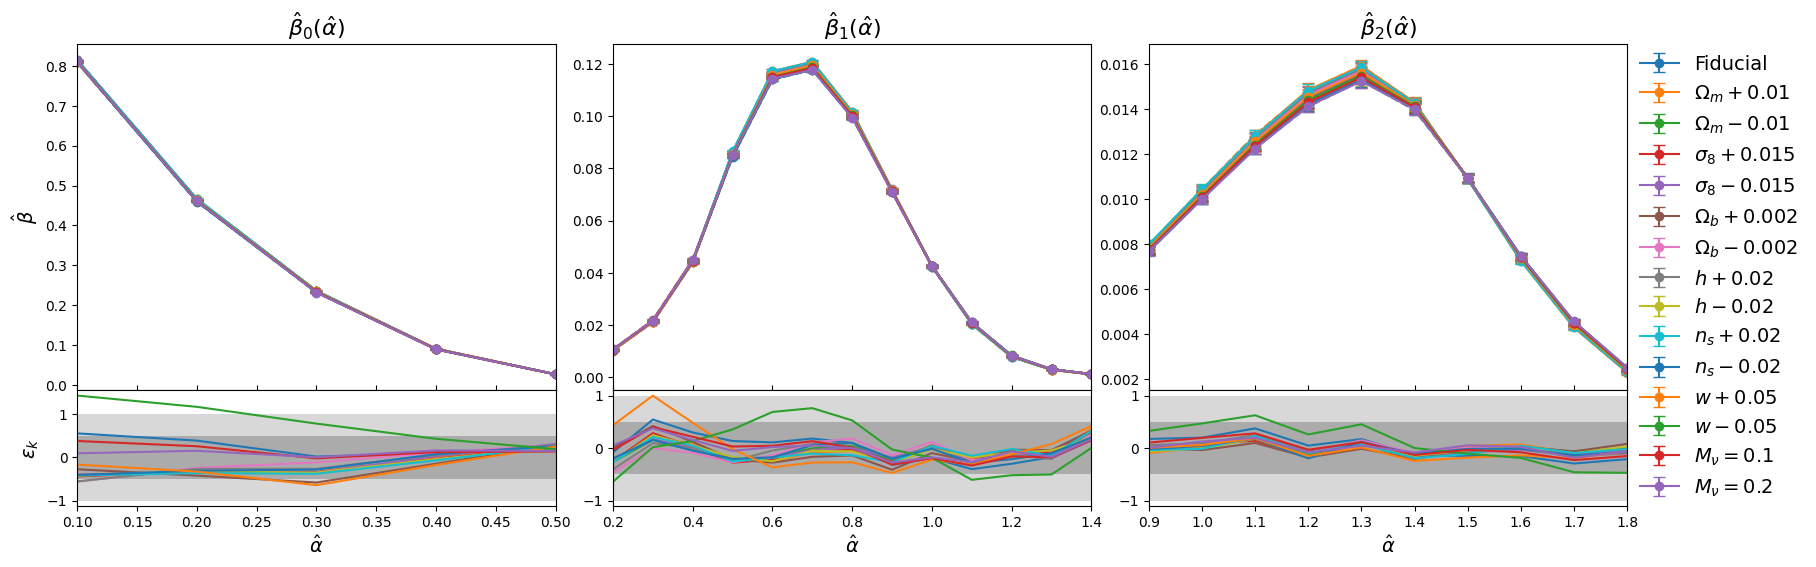

In [12]:
fig, axes = plt.subplots(2, 3, sharex='col', gridspec_kw={'height_ratios': [3, 1]}, figsize=(20,6))

for i in range(len(emulators_rsd)):
    # fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    ax1 = axes[0][i]
    ax2 = axes[1][i]
    for j in range(preds[i].shape[0]):
        c = ax1.errorbar(x[i], true[i][j], yerr=err_stat[i][j], fmt='-o', label=labels[j], capsize=4)[0].get_color()
        ax1.plot(x[i], preds[i][j,:], color=c, linestyle='--')

        ax2.plot(x[i], acc[i][j], color=c)

    xlim = ax2.get_xlim()
    ax2.fill_between(np.linspace(xlim[0],xlim[1],50), -0.5, 0.5, facecolor='gray', alpha=0.5)
    ax2.fill_between(np.linspace(xlim[0],xlim[1],50), -1, 1, facecolor='gray', alpha=0.3)
    ax2.set_xlim(x[i][0],x[i][-1])
    if i == 2:
        ax1.legend(frameon=False, bbox_to_anchor=(0.99, 1.02), loc='upper left', fontsize=14)
    ax1.tick_params(axis='x', direction='in')
    if i == 0:
        ax1.set_ylabel(r'$\hat\beta$', fontsize=14)
        ax2.set_ylabel(r'$\epsilon_k$', fontsize=14)
    ax1.set_title(rf'$\hat\beta_{i}(\hat\alpha)$', fontsize=16)
    
    ax2.set_xlabel(r'$\hat\alpha$', fontsize=14)
    plt.subplots_adjust(hspace=0)

plt.subplots_adjust(wspace=0.12)

# plt.savefig('../Fig/BC_rsdz_validation.pdf', bbox_inches='tight')

plt.show()

In [ ]:
RMSRE_2 = [RMSRE_sts, RMSRE_sts_rsdz] 
fig, axes = plt.subplots(3, 2, sharex=True, sharey='row', gridspec_kw={'height_ratios': [1, 1, 1]}, figsize=(11,5))
for i in range(len(RMSRE_2)):
    ax1 = axes[0][i]
    ax2 = axes[1][i]
    ax3 = axes[2][i]
    ax1.plot(x[0], RMSRE_2[i][0], label='BC0')
    ax2.plot(x[1], RMSRE_2[i][1], label='BC1')
    ax3.plot(x[2], RMSRE_2[i][2], label='BC2')

    ax1.tick_params(axis='both', direction='in',pad=10)
    ax2.tick_params(axis='both', direction='in',pad=10)
    ax3.tick_params(axis='both', direction='in')

    ax2.set_yticks((0.5,1))
    # ax1.set_xticks(x[0])
    # ax2.set_xticks(x[1])
    # ax3.set_xticks(x[2])

    if i == 0:
        ax1.set_ylabel(r'$\text{RMSE}_{\epsilon_0}$')
        ax2.set_ylabel(r'$\text{RMSE}_{\epsilon_1}$')
        ax3.set_ylabel(r'$\text{RMSE}_{\epsilon_2}$')
        # ax1.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left')

    if i == 1:
        ax1.set_title('w/ RSD')
    if i == 0:
        ax1.set_title('w/o RSD')

    ax3.set_xlabel(r'$\hat\alpha$')
    plt.subplots_adjust(hspace=0)
plt.subplots_adjust(wspace=0.02)
plt.savefig('/home/ljy/BettiCurveCosmo/Fig/RMSRE.pdf', dpi=300, bbox_inches='tight')
